# Eksploracyjna analiza danych i selekcja cech



In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [71]:
df = pd.read_parquet("data/clean_data.parquet")

target_col = "tran_cena_brutto"

numeric_features = [
    "nier_pow_gruntu",
    "lok_liczba_izb",
    "lok_nr_kond",
    "lok_pow_uzyt",
    "lok_pow_przyn",
    "dok_miesiac",
    "dok_rok",
    "coord_x",
    "coord_y",
]

categorical_features = [
    "tran_rodzaj_trans",
    "tran_rodzaj_rynku",
    "tran_sprzedajacy",
    "tran_kupujacy",
    "nier_prawo",
    "nier_udzial",
    "dzielnica",
    "Ulica",
]

results = []



## Analiza zmiennej docelowej

Poniżej przedstawiono histogram zmiennej `tran_cena_brutto`

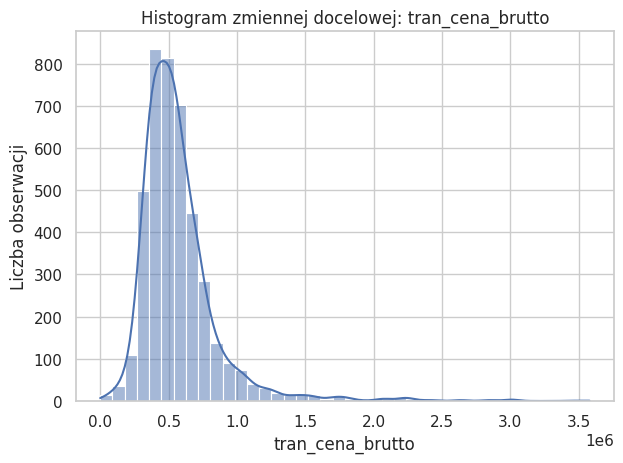

In [72]:
sns.histplot(data=df, x=target_col, bins=40, kde=True)
plt.title(f"Histogram zmiennej docelowej: {target_col}")
plt.xlabel(target_col)
plt.ylabel("Liczba obserwacji")
plt.tight_layout()
plt.show()


Na wykresie wyraźnie widać, że w zbiorze występują informację o bardzo drogich i bardzo tanich lokalach. Dane zostały zatem obcięte do 1 percentyla oraz od 99 percentyla.

In [73]:
# Progi 1% i 99% dla zmiennej docelowej
q01 = df[target_col].quantile(0.01)
q99 = df[target_col].quantile(0.99)

# Liczba wierszy przed
n_before = len(df)

# Ucinanie "na stałe" = usuwamy obserwacje poza zakresem [q01, q99]
df = df[(df[target_col] >= q01) & (df[target_col] <= q99)].copy()

# Liczba wierszy po
n_after = len(df)
n_cut = n_before - n_after
pct_cut = (n_cut / n_before) * 100

print(f"Próg 1%: {q01:,.2f}")
print(f"Próg 99%: {q99:,.2f}")
print(f"Wycięto rekordów: {n_cut} z {n_before} ({pct_cut:.2f}%)")
print(f"Nowy rozmiar df: {df.shape}")

Próg 1%: 170,000.00
Próg 99%: 1,789,491.44
Wycięto rekordów: 84 z 4231 (1.99%)
Nowy rozmiar df: (4147, 18)


Po tej operacji rozkład zmiennej `tran_cena_brutto` wygląda następująco:

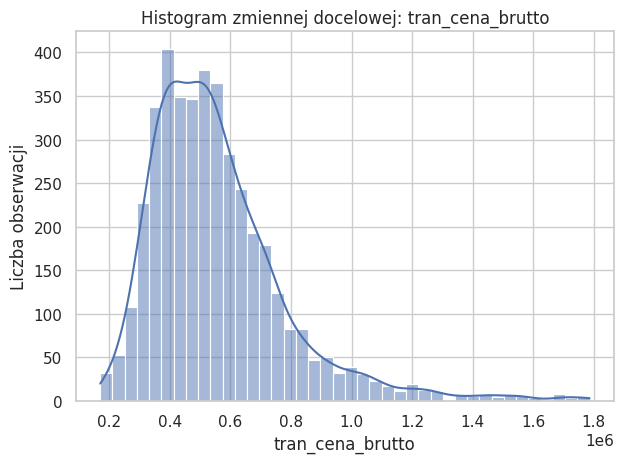

In [74]:
sns.histplot(data=df, x=target_col, bins=40, kde=True)
plt.title(f"Histogram zmiennej docelowej: {target_col}")
plt.xlabel(target_col)
plt.ylabel("Liczba obserwacji")
plt.tight_layout()
plt.show()

## Korelacja liniowa
Poniżej przedstawiono macież korelacji zmiennych ciągłych,

<Axes: >

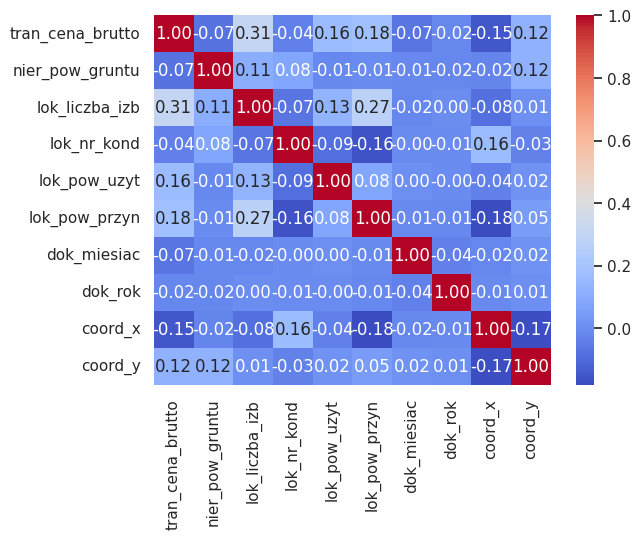

In [75]:
corr_matrix = df[[target_col] + numeric_features].corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=False)


Współczynniki korelacji dla każdej ze zmiennej są niskie, co oznacza, że nie występuje wyraźna korelacja liniowa między z zmienną docelową.

## Mutual information

Na poniższej tabeli przedstawiono wskaźnik `mutual information` między każdą ze zmiennych a zmienną docelową

In [76]:
results = []

# Zmienne numeryczne
for col in numeric_features:
    tmp = df[[col, target_col]].dropna()
    if tmp.empty:
        continue

    corr = tmp[col].corr(tmp[target_col])
    mi = mutual_info_regression(
        tmp[[col]],
        tmp[target_col],
        discrete_features=[False],
        random_state=42,
    )[0]

    results.append(
        {
            "feature": col,
            "dtype": "numeric",
            "mutual_information": mi,
            "unique_values": np.nan,
        }
    )

# Zmienne kategoryczne
for col in categorical_features:
    tmp = df[[col, target_col]].dropna()
    if tmp.empty:
        continue

    encoded = tmp[col].astype("category").cat.codes
    corr = encoded.corr(tmp[target_col])
    mi = mutual_info_regression(
        encoded.to_frame(name=col),
        tmp[target_col],
        discrete_features=[True],
        random_state=42,
    )[0]

    results.append(
        {
            "feature": col,
            "dtype": "categorical",
            "mutual_information": mi,
            "unique_values": tmp[col].nunique(),
        }
    )

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values("mutual_information", ascending=False).reset_index(drop=True)

summary_df


,feature,dtype,mutual_information,unique_values
0,lok_pow_uzyt,numeric,0.599414,NaN
1,Ulica,categorical,0.498830,414.0
2,coord_y,numeric,0.282951,NaN
3,coord_x,numeric,0.263256,NaN
4,dzielnica,categorical,0.232765,26.0
5,nier_pow_gruntu,numeric,0.230598,NaN
6,tran_rodzaj_trans,categorical,0.170855,3.0
7,tran_rodzaj_rynku,categorical,0.168873,2.0
8,tran_sprzedajacy,categorical,0.156380,2.0
9,lok_liczba_izb,numeric,0.152905,NaN


Na podstawie tego wskaźnika wybranych zostało 10 najistotniejszych cech, które będą wykorzystywane do budowania modeli,

## Analiza najistotniejszych cech


### lok_pow_uzyt


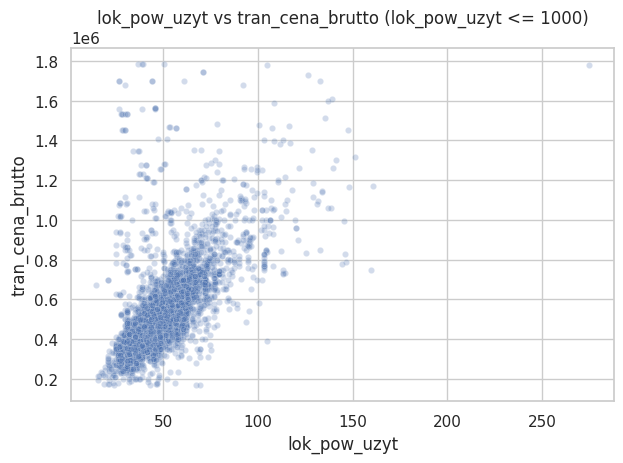

In [77]:
feature = "lok_pow_uzyt"
tmp = df[[feature, target_col]]
tmp_plot = tmp[tmp[feature] <= 1000]   # odcinamy tylko wartości > 1000
sns.scatterplot(data=tmp_plot, x=feature, y=target_col, alpha=0.25, s=20)
plt.title(f"{feature} vs {target_col} (lok_pow_uzyt <= 1000)")
plt.tight_layout()
plt.show()


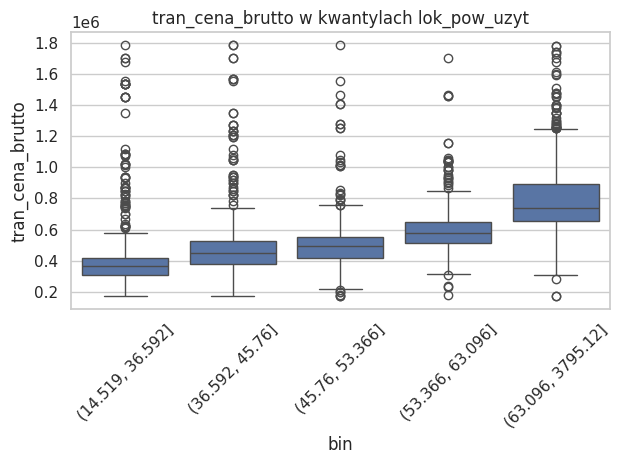

In [78]:
feature = "lok_pow_uzyt"

tmp = df[[feature, target_col]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[feature], q=5, duplicates="drop")
sns.boxplot(data=tmp, x="bin", y=target_col)
plt.xticks(rotation=45)
plt.title(f"{target_col} w kwantylach {feature}")
plt.tight_layout()
plt.show()


In [79]:
feature = "lok_pow_uzyt"

tmp = df[[feature, target_col]].dropna()

stats = tmp[feature].describe().to_frame(name="lok_pow_uzyt")
stats.loc["skew"] = tmp[feature].skew()
stats.loc["kurtosis"] = tmp[feature].kurtosis()


display(stats)


,lok_pow_uzyt
count,4147.000000
mean,53.249544
std,69.411608
min,14.520000
25%,38.700000
50%,48.540000
75%,60.445000
max,3795.120000
skew,42.949236
kurtosis,2153.203111


### coord_y


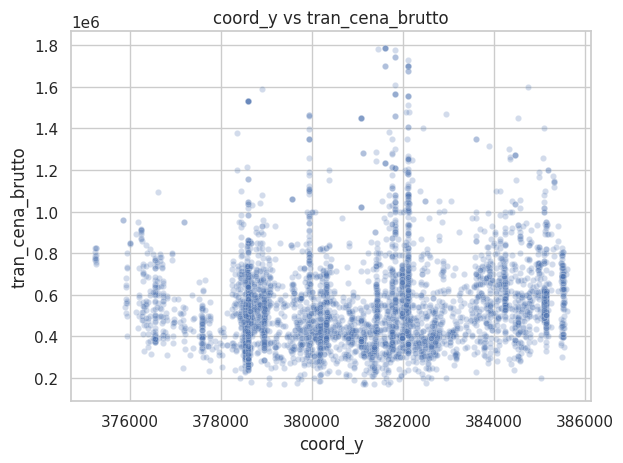

In [80]:
feature = "coord_y"

tmp = df[[feature, target_col]].dropna()
sns.scatterplot(data=tmp, x=feature, y=target_col, alpha=0.25, s=20)
plt.title(f"{feature} vs {target_col}")
plt.tight_layout()
plt.show()


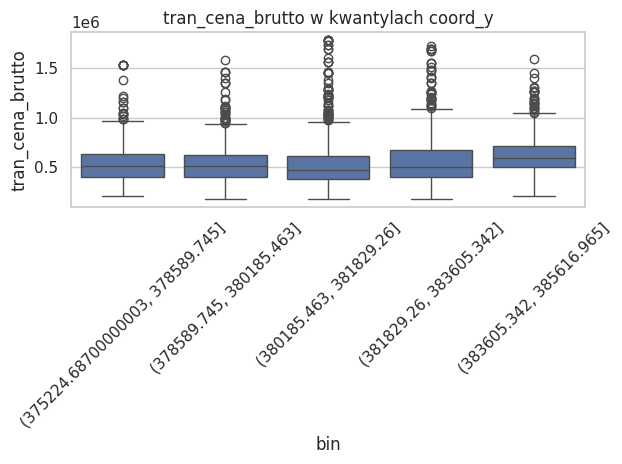

In [81]:
feature = "coord_y"

tmp = df[[feature, target_col]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[feature], q=5, duplicates="drop")
sns.boxplot(data=tmp, x="bin", y=target_col)
plt.xticks(rotation=45)
plt.title(f"{target_col} w kwantylach {feature}")
plt.tight_layout()
plt.show()


### coord_x


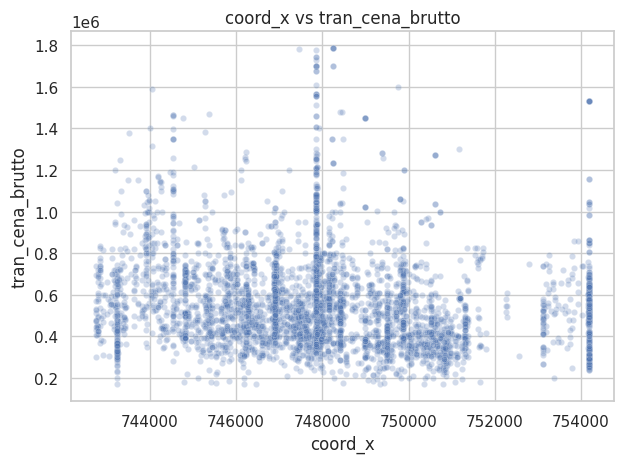

In [82]:
feature = "coord_x"

tmp = df[[feature, target_col]].dropna()
sns.scatterplot(data=tmp, x=feature, y=target_col, alpha=0.25, s=20)
plt.title(f"{feature} vs {target_col}")
plt.tight_layout()
plt.show()


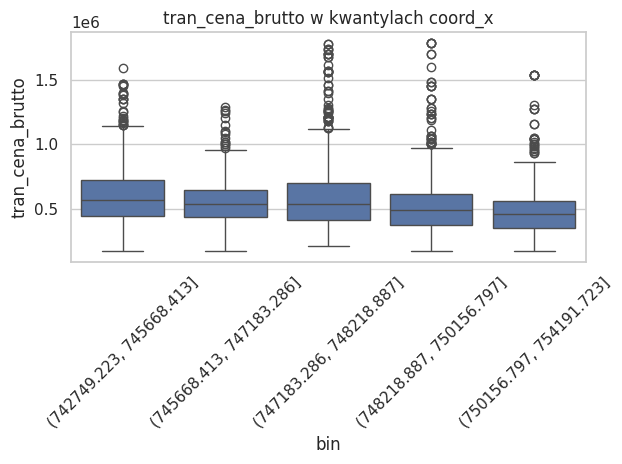

In [83]:
feature = "coord_x"

tmp = df[[feature, target_col]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[feature], q=5, duplicates="drop")
sns.boxplot(data=tmp, x="bin", y=target_col)
plt.xticks(rotation=45)
plt.title(f"{target_col} w kwantylach {feature}")
plt.tight_layout()
plt.show()


### nier_pow_gruntu


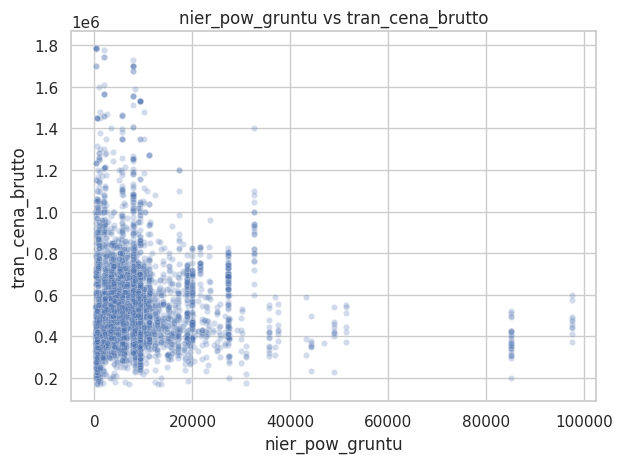

In [84]:
feature = "nier_pow_gruntu"

tmp = df[[feature, target_col]].dropna()
sns.scatterplot(data=tmp, x=feature, y=target_col, alpha=0.25, s=20)
plt.title(f"{feature} vs {target_col}")
plt.tight_layout()
plt.show()


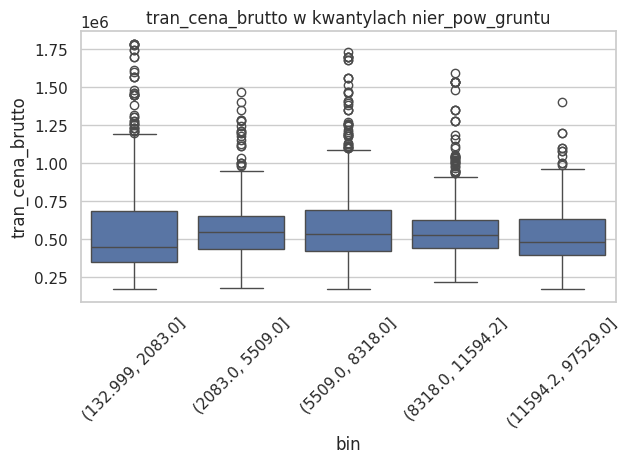

In [85]:
feature = "nier_pow_gruntu"

tmp = df[[feature, target_col]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[feature], q=5, duplicates="drop")
sns.boxplot(data=tmp, x="bin", y=target_col)
plt.xticks(rotation=45)
plt.title(f"{target_col} w kwantylach {feature}")
plt.tight_layout()
plt.show()


In [86]:
feature = "nier_pow_gruntu"

tmp = df[[feature, target_col]].dropna()

stats = tmp[feature].describe().to_frame(name="nier_pow_gruntu")
stats.loc["skew"] = tmp[feature].skew()
stats.loc["kurtosis"] = tmp[feature].kurtosis()


display(stats)


,nier_pow_gruntu
count,4147.000000
mean,9005.661924
std,10718.454404
min,133.000000
25%,3004.500000
50%,6741.000000
75%,10025.000000
max,97529.000000
skew,4.209589
kurtosis,26.136964


### dzielnica


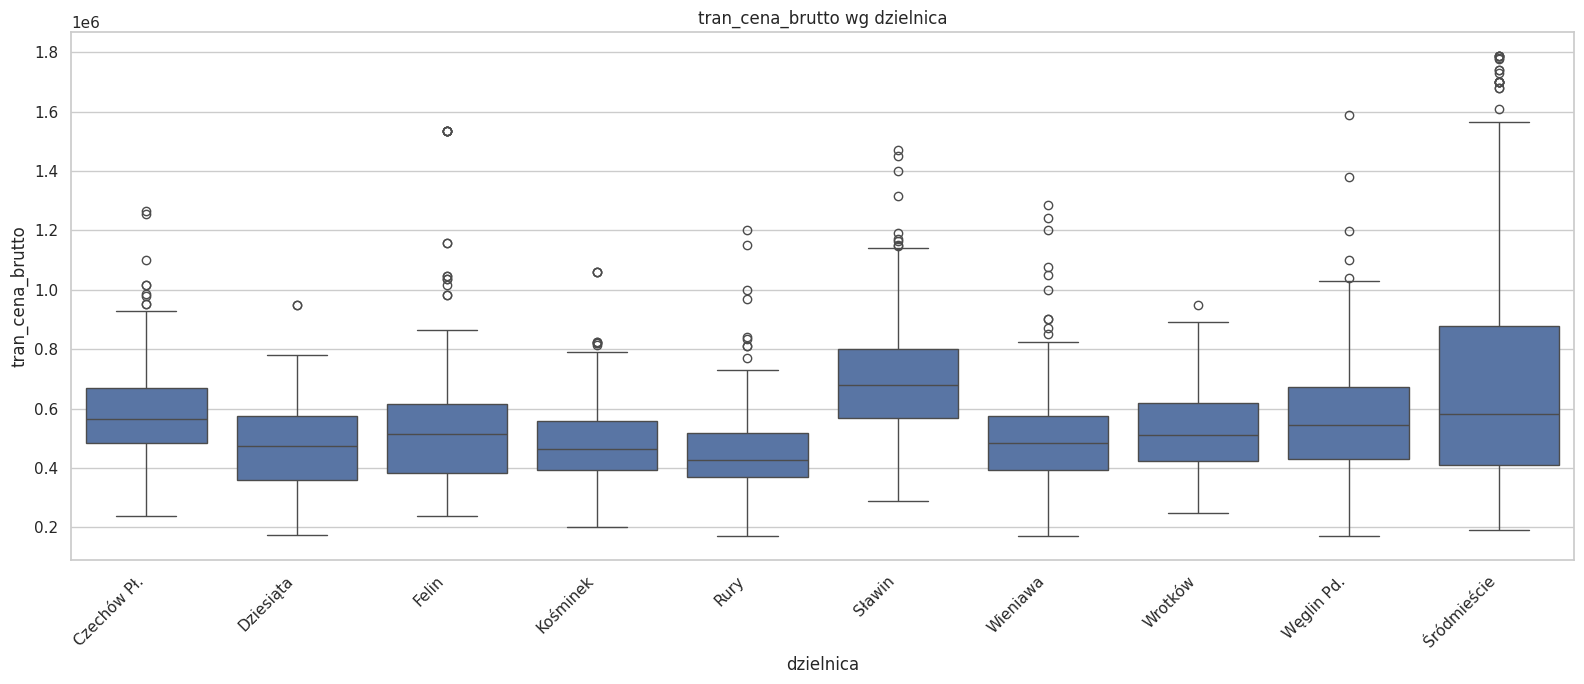

In [87]:
feature = "dzielnica"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
plot_df = tmp[tmp[feature].isin(top_cats)].copy()
plot_df[feature] = plot_df[feature].cat.remove_unused_categories()
plt.figure(figsize=(16, 7)) 
sns.boxplot(data=plot_df, x=feature, y=target_col)
plt.xticks(rotation=45, ha="right")
plt.title(f"{target_col} wg {feature}")
plt.tight_layout()
plt.show()


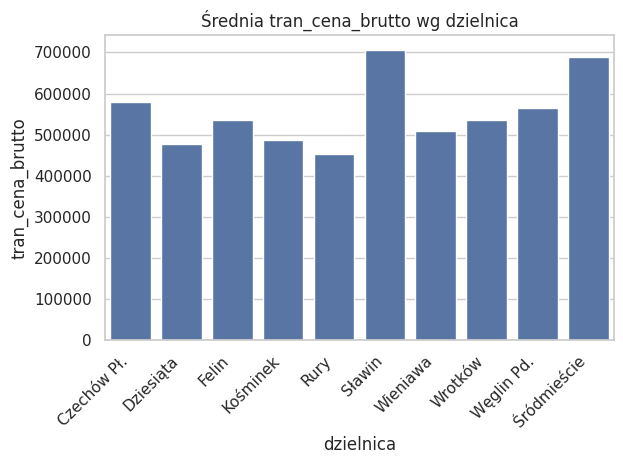

In [88]:
feature = "dzielnica"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
plot_df = tmp[tmp[feature].isin(top_cats)].copy()
plot_df[feature] = plot_df[feature].cat.remove_unused_categories()
agg_df = (
    plot_df.groupby(feature, dropna=False, observed=False)[target_col]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=agg_df, x=feature, y=target_col)
plt.xticks(rotation=45, ha="right")
plt.title(f"Średnia {target_col} wg {feature}")
plt.tight_layout()
plt.show()


In [89]:
feature = "dzielnica"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
stats_df = tmp[tmp[feature].isin(top_cats)].copy()
stats_df[feature] = stats_df[feature].cat.remove_unused_categories()
group_stats = (
    stats_df.groupby(feature, dropna=False, observed=False)[target_col]
    .agg(["count", "mean", "std", "min", "median", "max", "skew"])
    .sort_values("mean", ascending=False)
)

group_stats["kurtosis"] = stats_df.groupby(feature, dropna=False, observed=False)[target_col].apply(pd.Series.kurt)


display(group_stats)


,count,mean,std,min,median,max,skew,kurtosis
dzielnica,,,,,,,,
Sławin,225,706155.897778,206723.224435,289095.32,680000.00,1470000.00,0.939690,1.480033
Śródmieście,535,689540.668019,356344.336947,191197.23,582881.08,1786104.00,1.225212,0.982374
Czechów Pł.,421,580606.267648,151742.287584,240000.00,565000.00,1264000.00,0.746732,1.649159
Węglin Pd.,318,564651.268648,189562.331118,170000.00,544000.00,1590000.00,1.102143,3.133887
Wrotków,218,534845.556101,136923.011080,250000.00,510000.00,950000.00,0.505553,-0.349545
Felin,324,534536.423364,218264.397494,238546.00,515000.00,1533485.61,2.024801,6.781296
Wieniawa,213,509868.403850,173267.483062,172500.00,485000.00,1286080.00,1.600901,4.196927
Kośminek,324,487095.618210,136275.045867,200000.00,464070.85,1060000.00,0.992728,1.942185
Dziesiąta,210,477501.052952,145033.747312,173000.00,473428.00,950000.00,0.455159,-0.116183


### tran_rodzaj_trans


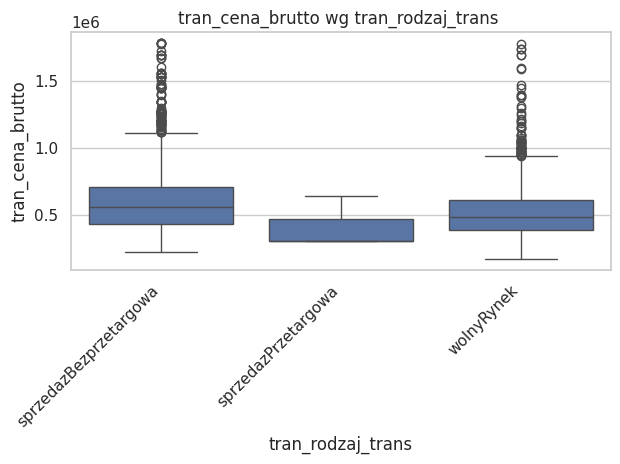

In [90]:
feature = "tran_rodzaj_trans"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
plot_df = tmp[tmp[feature].isin(top_cats)].copy()

sns.boxplot(data=plot_df, x=feature, y=target_col)
plt.xticks(rotation=45, ha="right")
plt.title(f"{target_col} wg {feature} ")
plt.tight_layout()
plt.show()


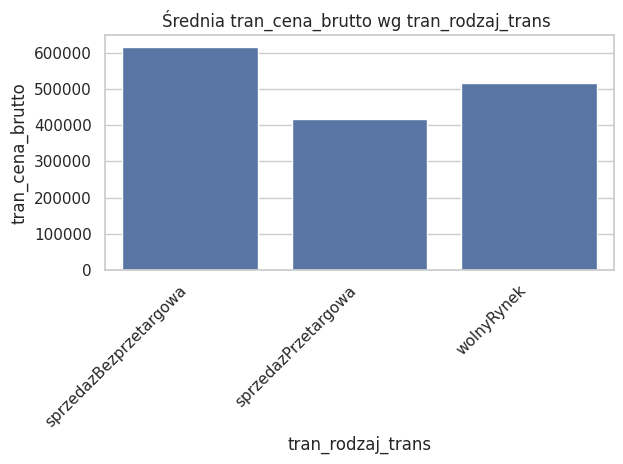

In [91]:
feature = "tran_rodzaj_trans"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
plot_df = tmp[tmp[feature].isin(top_cats)].copy()

agg_df = (
    plot_df.groupby(feature, dropna=False, observed=False)[target_col]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=agg_df, x=feature, y=target_col)
plt.xticks(rotation=45, ha="right")
plt.title(f"Średnia {target_col} wg {feature} ")
plt.tight_layout()
plt.show()


In [92]:
feature = "tran_rodzaj_trans"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
stats_df = tmp[tmp[feature].isin(top_cats)].copy()

group_stats = (
    stats_df.groupby(feature, dropna=False, observed=False)[target_col]
    .agg(["count", "mean", "std", "min", "median", "max", "skew"])
    .sort_values("mean", ascending=False)
)

group_stats["kurtosis"] = stats_df.groupby(feature, dropna=False, observed=False)[target_col].apply(pd.Series.kurt)


display(group_stats)


,count,mean,std,min,median,max,skew,kurtosis
tran_rodzaj_trans,,,,,,,,
sprzedazBezprzetargowa,1729,616758.908386,262756.996122,225892.94,559787.5,1786104.0,1.584049,3.150744
wolnyRynek,2415,516241.809453,191521.587604,170000.00,485000.0,1780000.0,1.586154,5.339667
sprzedazPrzetargowa,3,417666.666667,191680.289371,307000.00,307000.0,639000.0,1.732051,NaN


### tran_rodzaj_rynku


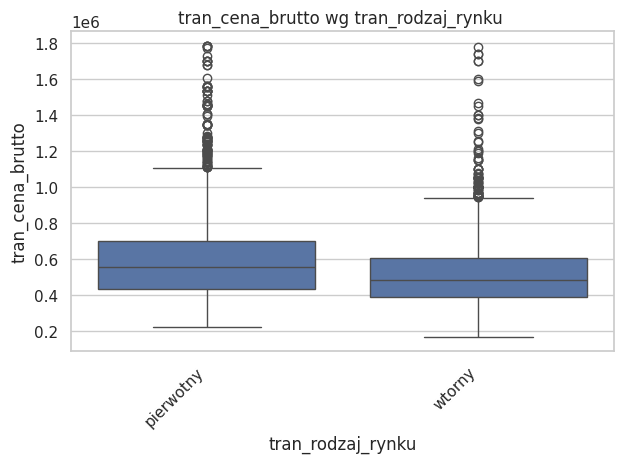

In [93]:
feature = "tran_rodzaj_rynku"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
plot_df = tmp[tmp[feature].isin(top_cats)].copy()

sns.boxplot(data=plot_df, x=feature, y=target_col)
plt.xticks(rotation=45, ha="right")
plt.title(f"{target_col} wg {feature} ")
plt.tight_layout()
plt.show()


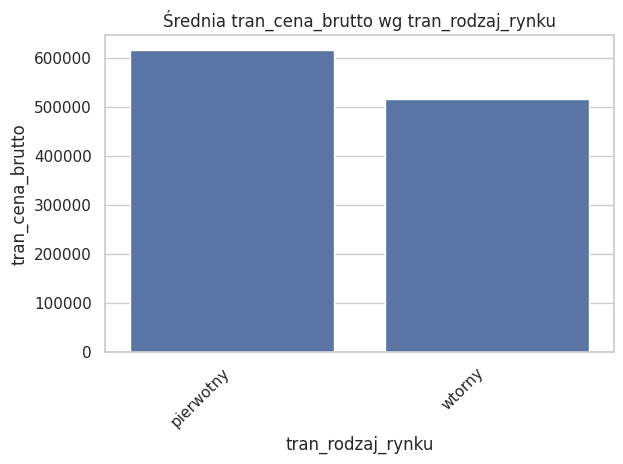

In [94]:
feature = "tran_rodzaj_rynku"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
plot_df = tmp[tmp[feature].isin(top_cats)].copy()

agg_df = (
    plot_df.groupby(feature, dropna=False, observed=False)[target_col]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=agg_df, x=feature, y=target_col)
plt.xticks(rotation=45, ha="right")
plt.title(f"Średnia {target_col} wg {feature} (top 10)")
plt.tight_layout()
plt.show()


In [95]:
feature = "tran_rodzaj_rynku"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
stats_df = tmp[tmp[feature].isin(top_cats)].copy()

group_stats = (
    stats_df.groupby(feature, dropna=False, observed=False)[target_col]
    .agg(["count", "mean", "std", "min", "median", "max", "skew"])
    .sort_values("mean", ascending=False)
)

group_stats["kurtosis"] = stats_df.groupby(feature, dropna=False, observed=False)[target_col].apply(pd.Series.kurt)

print("Statystyki {target_col} w grupach kategorii (top 10):")
display(group_stats)


,count,mean,std,min,median,max,skew,kurtosis
tran_rodzaj_rynku,,,,,,,,
pierwotny,1725,615730.223107,262740.917135,225892.94,557796.0,1786104.0,1.591256,3.183026
wtorny,2422,517018.368113,192092.757111,170000.00,487000.0,1780000.0,1.578381,5.253758


### lok_liczba_izb


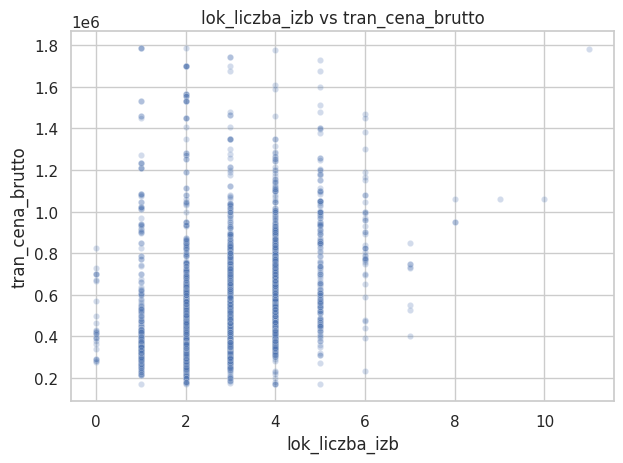

In [96]:
feature = "lok_liczba_izb"

tmp = df[[feature, target_col]].dropna()
sns.scatterplot(data=tmp, x=feature, y=target_col, alpha=0.25, s=20)
plt.title(f"{feature} vs {target_col}")
plt.tight_layout()
plt.show()


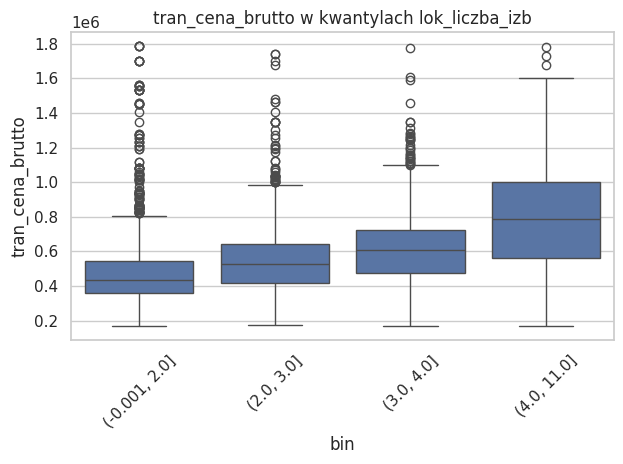

In [97]:
feature = "lok_liczba_izb"

tmp = df[[feature, target_col]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[feature], q=5, duplicates="drop")
sns.boxplot(data=tmp, x="bin", y=target_col)
plt.xticks(rotation=45)
plt.title(f"{target_col} w kwantylach {feature}")
plt.tight_layout()
plt.show()


In [98]:
feature = "lok_liczba_izb"

tmp = df[[feature, target_col]].dropna()

stats = tmp[feature].describe().to_frame(name="lok_liczba_izb")
stats.loc["skew"] = tmp[feature].skew()
stats.loc["kurtosis"] = tmp[feature].kurtosis()


display(stats)


,lok_liczba_izb
count,4147.0
mean,2.93224
std,1.070586
min,0.0
25%,2.0
50%,3.0
75%,4.0
max,11.0
skew,0.494848
kurtosis,1.906072


### tran_sprzedajacy


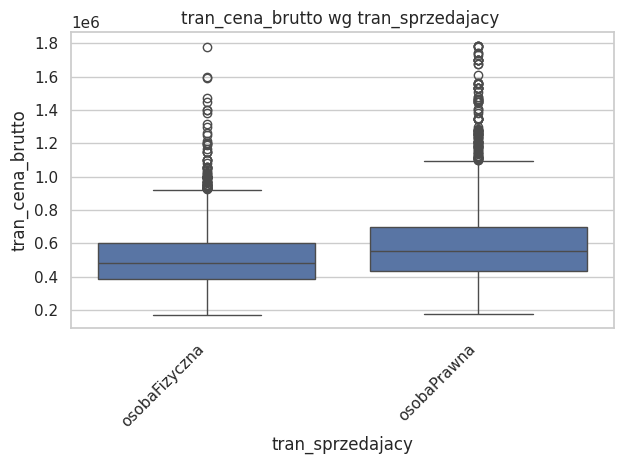

In [99]:
feature = "tran_sprzedajacy"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
plot_df = tmp[tmp[feature].isin(top_cats)].copy()

sns.boxplot(data=plot_df, x=feature, y=target_col)
plt.xticks(rotation=45, ha="right")
plt.title(f"{target_col} wg {feature} ")
plt.tight_layout()
plt.show()


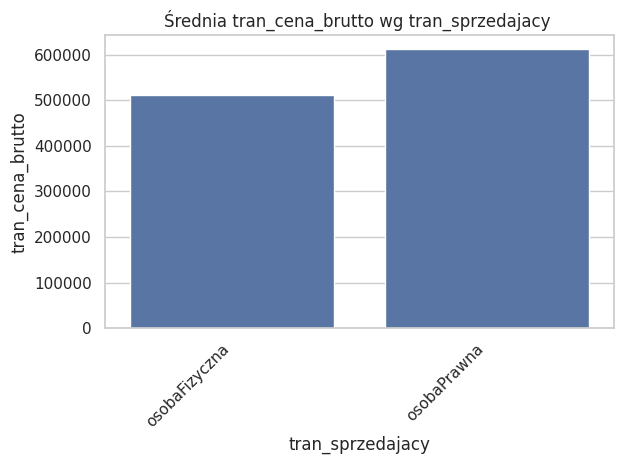

In [100]:
feature = "tran_sprzedajacy"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
plot_df = tmp[tmp[feature].isin(top_cats)].copy()

agg_df = (
    plot_df.groupby(feature, dropna=False, observed=False)[target_col]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=agg_df, x=feature, y=target_col)
plt.xticks(rotation=45, ha="right")
plt.title(f"Średnia {target_col} wg {feature} ")
plt.tight_layout()
plt.show()


In [101]:
feature = "tran_sprzedajacy"

tmp = df[[feature, target_col]].dropna()
top_cats = tmp[feature].value_counts().head(10).index
stats_df = tmp[tmp[feature].isin(top_cats)].copy()

group_stats = (
    stats_df.groupby(feature, dropna=False, observed=False)[target_col]
    .agg(["count", "mean", "std", "min", "median", "max", "skew"])
    .sort_values("mean", ascending=False)
)

group_stats["kurtosis"] = stats_df.groupby(feature, dropna=False, observed=False)[target_col].apply(pd.Series.kurt)


display(group_stats)


,count,mean,std,min,median,max,skew,kurtosis
tran_sprzedajacy,,,,,,,,
osobaPrawna,1921,611466.221166,260726.378719,175000.0,555563.57,1786104.0,1.664143,3.596494
osobaFizyczna,2226,512006.519124,186565.352076,170000.0,480000.00,1780000.0,1.361919,3.709798


In [102]:
df.to_parquet("data/final_data.parquet", engine="pyarrow", index=False)